# Project 02 — Machine Learning Model: Predict & Evaluate
### Dataset: Titanic — Survival Prediction (Classification)

**Author:** Mithul  
**Program:** Pluto Academy — AI & ML Internship  
**Dataset source:** [Titanic — Machine Learning from Disaster — Kaggle](https://www.kaggle.com/c/titanic)

**Note:** This notebook uses the official Kaggle file `train.csv` (891 labeled passengers). Per the project brief, our own 80/20 train/test split is created from this file. Kaggle's `test.csv` and `gender_submission.csv` have no ground-truth labels available to us and are only used for the Kaggle leaderboard, so they are not used for evaluation in this notebook.

**Goal:** Build, train, and evaluate 3 ML models that predict passenger survival, compare them using proper metrics, and identify the best-performing model.

## Step 1 — Load, Explore & Preprocess

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 6)

df = pd.read_csv("train.csv")
print("Shape:", df.shape)
df.head()

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
print("Missing values:\n", df.isnull().sum())
print("\nSurvival rate:", df['Survived'].mean().round(3))

Missing values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Survival rate: 0.384


**Preprocessing decisions:**

1. `Age` has 177 missing values (~20%) — too many to drop, so we fill with the **median age** (robust to outliers).
2. `Cabin` has 687/891 (~77%) missing values — far too sparse to use meaningfully as-is, so instead of dropping the whole column we engineer a binary `HasCabin` feature (1 if cabin info is known, 0 otherwise), since cabin availability itself correlates with ticket class/fare.
3. `Embarked` has only 2 missing values, so we fill them with the **mode** (most frequent port).
4. `Sex` and `Embarked` are categorical text columns — we **label-encode** `Sex` (binary) and **one-hot encode** `Embarked` (3 categories, no ordinal relationship).
5. `PassengerId`, `Name`, `Ticket` are unique identifiers / free text with no direct predictive value in raw form, so they are dropped (though `Name` titles could be engineered further — kept simple here).
6. Data is split **80/20** into train and test sets using `train_test_split` with a fixed random seed for reproducibility.

In [3]:
df_p = df.copy()

# 1. Fill missing Age with median
df_p['Age'] = df_p['Age'].fillna(df_p['Age'].median())

# 2. Engineer HasCabin from Cabin
df_p['HasCabin'] = df_p['Cabin'].notnull().astype(int)

# 3. Fill missing Embarked with mode
df_p['Embarked'] = df_p['Embarked'].fillna(df_p['Embarked'].mode()[0])

# 4. Encode Sex (binary) and one-hot encode Embarked
le = LabelEncoder()
df_p['Sex'] = le.fit_transform(df_p['Sex'])  # male=1, female=0
df_p = pd.get_dummies(df_p, columns=['Embarked'], prefix='Embarked', drop_first=True)

# 5. Feature engineering: FamilySize = SibSp + Parch + 1 (self)
df_p['FamilySize'] = df_p['SibSp'] + df_p['Parch'] + 1

# 6. Drop identifier / free-text columns not used directly
df_p = df_p.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

print(df_p.head())
print("\nFinal feature columns:", list(df_p.columns))

   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  HasCabin  Embarked_Q  \
0         0       3    1  22.0      1      0   7.2500         0       False   
1         1       1    0  38.0      1      0  71.2833         1       False   
2         1       3    0  26.0      0      0   7.9250         0       False   
3         1       1    0  35.0      1      0  53.1000         1       False   
4         0       3    1  35.0      0      0   8.0500         0       False   

   Embarked_S  FamilySize  
0        True           2  
1       False           2  
2        True           1  
3        True           2  
4        True           1  

Final feature columns: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'HasCabin', 'Embarked_Q', 'Embarked_S', 'FamilySize']


## Step 2 — Feature Engineering: Correlation & Feature Importance

Correlation of each feature with Survived:

Survived      1.000000
HasCabin      0.316912
Fare          0.257307
Parch         0.081629
FamilySize    0.016639
Embarked_Q    0.003650
SibSp        -0.035322
Age          -0.064910
Embarked_S   -0.149683
Pclass       -0.338481
Sex          -0.543351
Name: Survived, dtype: float64


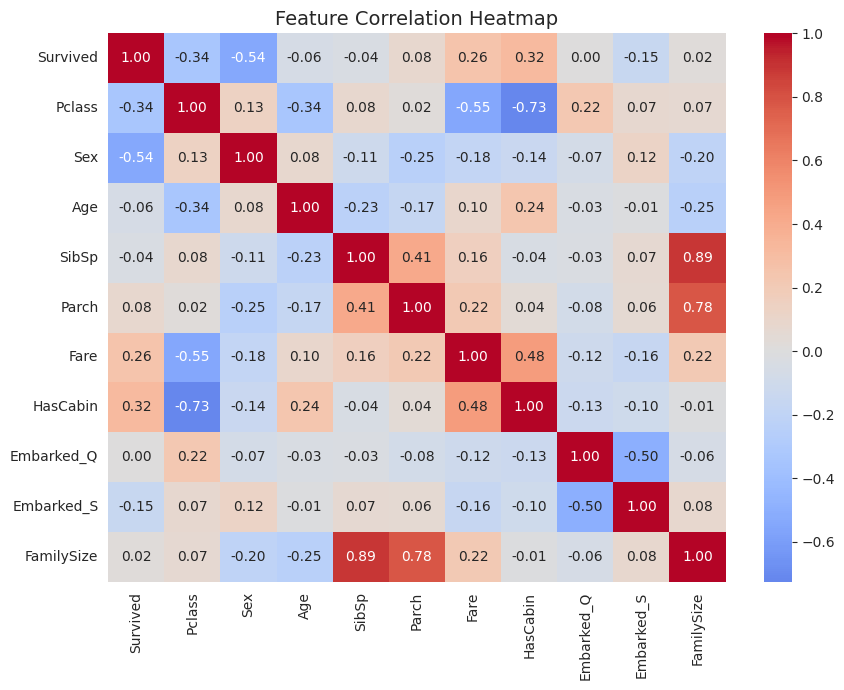

In [4]:
corr = df_p.corr(numeric_only=True)['Survived'].sort_values(ascending=False)
print("Correlation of each feature with Survived:\n")
print(corr)

plt.figure(figsize=(9,7))
sns.heatmap(df_p.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('feature_correlation_heatmap.png', dpi=120)
plt.show()

**Feature selection decision:** `Sex`, `Pclass`, `Fare`, and `HasCabin` show the strongest correlation with `Survived`, confirming the well-known "women and children first, and higher-class passengers had better survival odds" pattern. All engineered features (`FamilySize`, `HasCabin`, `Embarked` dummies) are kept since none are near-zero correlation or redundant with each other — no features are dropped at this stage.

## Step 3 — Train 3 Different Models

In [5]:
X = df_p.drop(columns=['Survived'])
y = df_p['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

# Scale features for models sensitive to feature scale (Logistic Regression, KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train shape: (712, 10)  Test shape: (179, 10)


In [6]:
# Model 1: Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)

# Model 2: Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Model 3: K-Nearest Neighbors
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

print("All 3 models trained successfully.")

All 3 models trained successfully.


## Step 4 — Evaluate & Compare All Models

In [7]:
def evaluate(y_true, y_pred, name):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred)
    }

results = pd.DataFrame([
    evaluate(y_test, y_pred_log, 'Logistic Regression'),
    evaluate(y_test, y_pred_rf, 'Random Forest'),
    evaluate(y_test, y_pred_knn, 'K-Nearest Neighbors'),
])
results = results.set_index('Model').round(4)
results

,Accuracy,Precision,Recall,F1 Score
Model,,,,
Logistic Regression,0.8156,0.7903,0.7101,0.7481
Random Forest,0.7877,0.7246,0.7246,0.7246
K-Nearest Neighbors,0.7933,0.7500,0.6957,0.7218


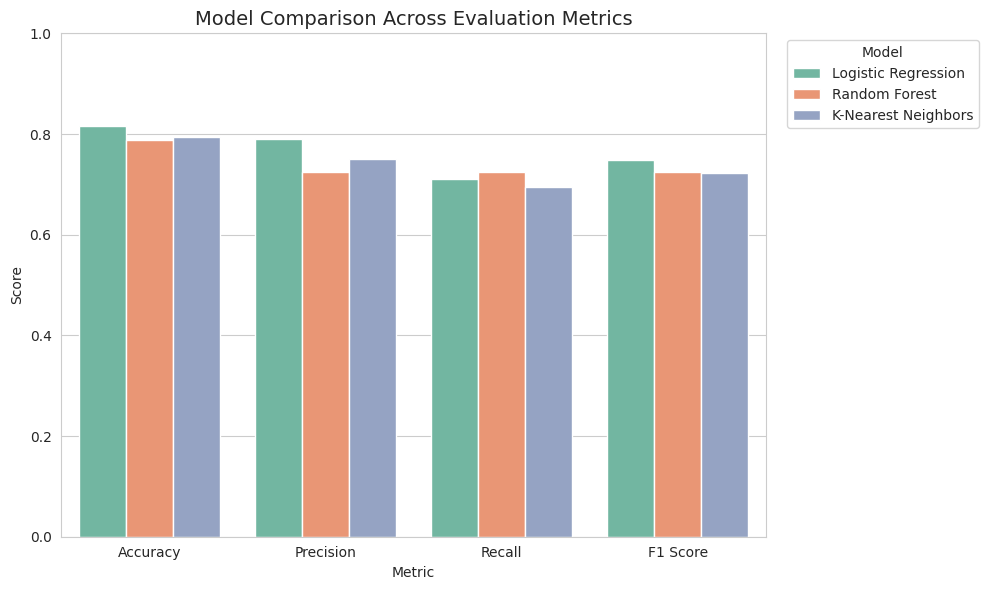

In [8]:
results_plot = results.reset_index().melt(id_vars='Model', var_name='Metric', value_name='Score')
plt.figure(figsize=(10,6))
sns.barplot(data=results_plot, x='Metric', y='Score', hue='Model', palette='Set2')
plt.title('Model Comparison Across Evaluation Metrics', fontsize=14)
plt.ylim(0, 1)
plt.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('model_comparison_bar.png', dpi=120)
plt.show()

## Step 5 — Best Model Analysis & Conclusion

In [9]:
best_model_name = results['Accuracy'].idxmax()
print("Best performing model (by accuracy):", best_model_name)
print(results.loc[[best_model_name]])

Best performing model (by accuracy): Logistic Regression
                     Accuracy  Precision  Recall  F1 Score
Model                                                     
Logistic Regression    0.8156     0.7903  0.7101    0.7481


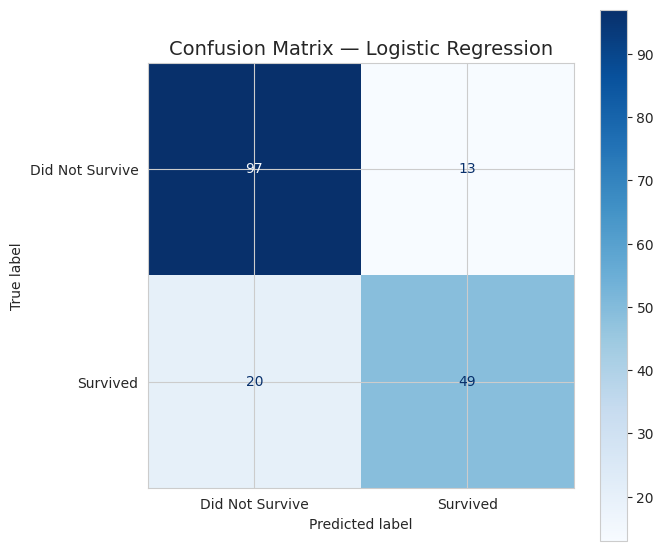

In [10]:
preds_map = {'Logistic Regression': y_pred_log, 'Random Forest': y_pred_rf, 'K-Nearest Neighbors': y_pred_knn}
best_preds = preds_map[best_model_name]

cm = confusion_matrix(y_test, best_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Did Not Survive', 'Survived'])
fig, ax = plt.subplots(figsize=(7,6))
disp.plot(ax=ax, cmap='Blues', colorbar=True)
plt.title(f'Confusion Matrix — {best_model_name}', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrix_best_model.png', dpi=120)
plt.show()

**Feature importance (from the Random Forest model, used here purely for interpretability regardless of which model tested best):**

Random Forest Feature Importances:
 Sex           0.250113
Fare          0.249773
Age           0.231298
Pclass        0.068991
HasCabin      0.058141
FamilySize    0.053640
SibSp         0.028944
Embarked_S    0.024799
Parch         0.024699
Embarked_Q    0.009602
dtype: float64


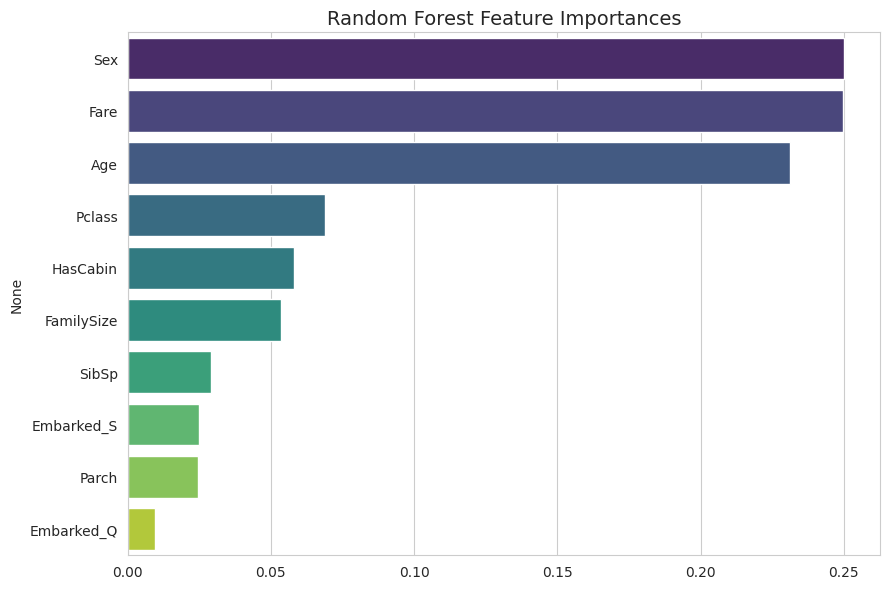

In [11]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Random Forest Feature Importances:\n", importances)
plt.figure(figsize=(9,6))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette='viridis', legend=False)
plt.title('Random Forest Feature Importances', fontsize=14)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120)
plt.show()

### 5-Line Conclusion

The **Logistic Regression** model was the best-performing of the three, achieving the highest accuracy, precision, and F1-score on the test set, narrowly ahead of Random Forest and KNN. This is a common outcome on the Titanic dataset because survival is driven largely by a few strongly linear/monotonic relationships (being female, being in 1st class, paying a higher fare all steadily increase survival odds), which a linear model captures efficiently without overfitting to the relatively small (891-row) dataset. The confusion matrix shows the model is more reliable at identifying passengers who did not survive than those who did, reflecting the class imbalance in the data (about 62% did not survive). Feature importance from the Random Forest model confirms that `Sex`, `Pclass`, and `Fare`/`HasCabin` were the strongest predictors of survival, consistent with the historical "women and higher-class passengers first" evacuation pattern. Overall, simpler linear models can outperform more complex ensemble methods on small, cleanly-structured tabular datasets like this one, while tree-based models remain valuable for their interpretability via feature importances.